In [1]:
from utils import *
from genData import *
from model.unet_leaky_norm_tanho import UNet
import time 
np.random.seed(111)
torch.manual_seed(111)

det = 'H1L1'
f0 = 500
size = (512, 64)
Tsft = 14400

max_train_levels = [0, 9, 12, 15, 17, 18, 19, 20, 21, 22, 28, 35, 40, 50, 60]


filename = '/scratch/kriles_root/kriles0/damoncht/unet_f/data/validation/{0}Hz_H1L1_D0-{4}_{1}x{2}_{3}s_4c_traindata_n{5}_seed0_2323.npz'.format(f0, size[0], size[1], Tsft, 35, 400)
targets = np.load(filename, allow_pickle=True)['clean_image']
masks = np.load(filename, allow_pickle=True)['signal_mask']

data = []
mask_data = []
target_data = []
label_data = []
for Sn in max_train_levels:
    noise = np.empty((targets.shape[0],) + size + (4,))
    for i in range(noise.shape[0]):
        noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)

    data.append(normalize(noise + targets))
    mask_data.append(masks)
    target_data.append(normalize(targets))
    labels = [Sn] * noise.shape[0]  # Extend labels
    label_data.append(labels)
        
data = np.concatenate(data)
mask_data = np.concatenate(mask_data)
target_data = np.concatenate(target_data)
label_data = np.concatenate(label_data)
data = load_signal_datasetv2(data, target_data, mask_data, label_data)
    
    
noise = np.empty((400,) + size + (4,))
for i in range(noise.shape[0]):
    noise[i] = simNoise(sqrtSn=1, Tsft=Tsft, size=size, ndet=2, norm=False)
noise = normalize(noise)
noise_data = load_noise_dataset(noise)

val_loader = make_data_loader([data, noise_data], batch_size=8, shuffle=False)


25-06-13 00:12:14.858 pyfstat INFO    : Running PyFstat version 2.1.0


/home/damoncht/.conda/envs/ml/lib/python3.9/site-packages/pyfstat/core.py:12: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [1]:
from utils import *
from genData import *
from model.unet_leaky_norm_tanho import UNet
import time 
np.random.seed(111)
torch.manual_seed(111)


25-06-17 02:13:45.504 pyfstat INFO    : Running PyFstat version 2.1.0


/home/damoncht/.conda/envs/ml/lib/python3.9/site-packages/pyfstat/core.py:12: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


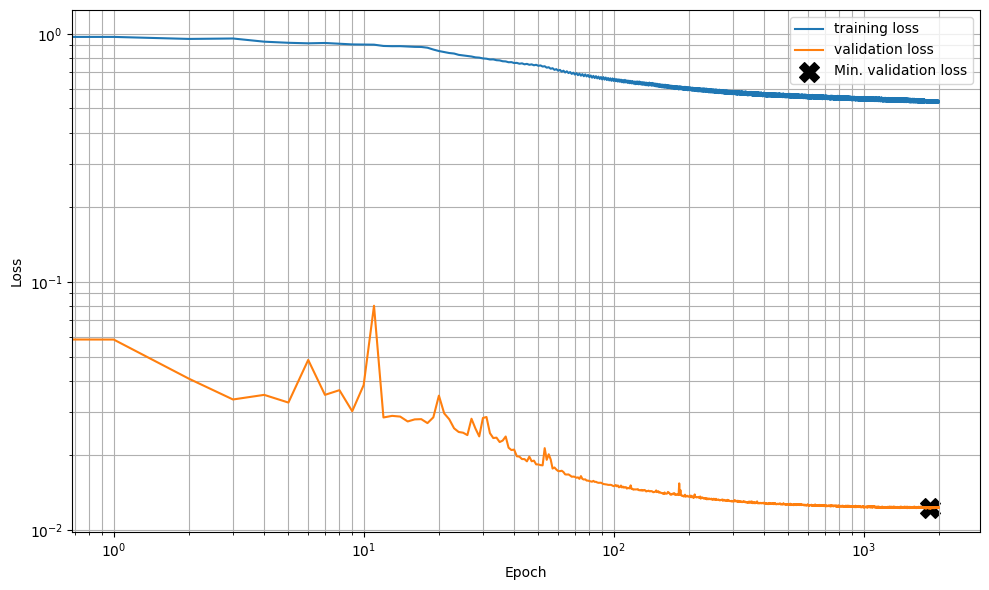

In [2]:
import numpy as np
from model.unet_leaky_norm_tanho_classification import UNet
import matplotlib.pyplot as plt

version = 'H1L1_fast_UNET_weight_alpha1.0beta1.0_500Hz_D22-22_T10_Tsft14400_ndata5_step2_ndata5000_th50_512x64_MSELoss_dropout0'
data = np.load('/scratch/kriles_root/kriles0/damoncht/unet_f/trained_model/{}Hz/losses_{}.npy'.format(f0, version), allow_pickle=True)
train_pdet = data.item()['train_pdet']
val_pdet = data.item()['val_pdet']

train_losses = data.item()['train_losses']
val_losses = data.item()['val_losses']
top_val_loss = data.item()['top_val_losses']

train_pdet = data.item()['train_pdet']
val_pdet = data.item()['val_pdet']

plt.figure(figsize=(10, 6))
plt.plot(train_losses[5:]/train_losses[5:].max(), label='training loss')
plt.plot(val_losses/val_losses.max(), label='validation loss')
idx = np.argmin(val_losses-top_val_loss)
plt.scatter(idx, top_val_loss/val_losses.max(), color='k', marker='X', label='Min. validation loss', s=200)

plt.yscale('log')
plt.xscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.minorticks_on()
plt.grid(which='both')
plt.tight_layout()
#plt.savefig('./plots/loss_{}.pdf'.format(version))
#plt.savefig('./plots/loss_{}.png'.format(version))
plt.show()


dict_keys([15, 18, 19, 20, 21, 35])


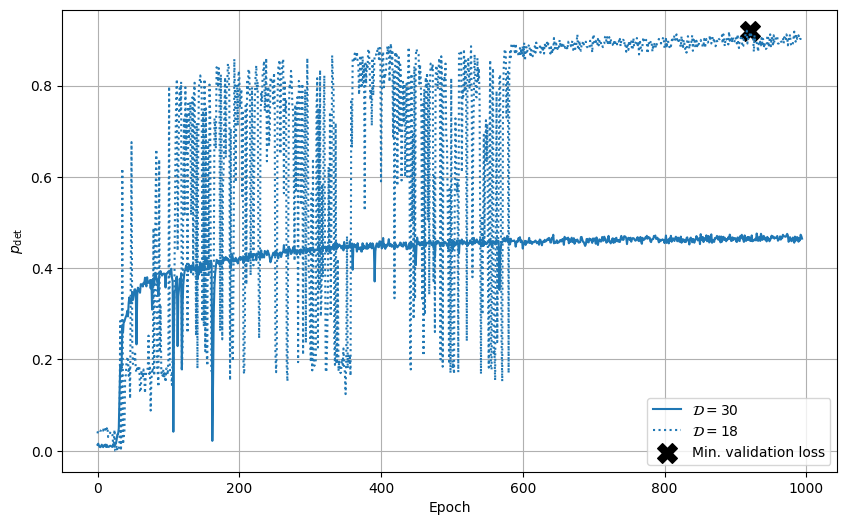

In [1]:
import numpy as np
from model.unet_leaky_norm_tanho_classification import UNet
import matplotlib.pyplot as plt

colors = plt.rcParams['axes.prop_cycle'].by_key()['color'] 
plt.figure(figsize=(10, 6))



data = np.load('/scratch/kriles_root/kriles0/damoncht/unet_f/trained_model/500Hz/losses_H1L1_UNET_alpha1.0beta1.0_500Hz_D20-20_T10_Tsft3600_step1_ndata5000_th50_128x256_MSELoss_dropout0.npy', allow_pickle=True)
train_pdet = data.item()['train_pdet']
val_pdet = data.item()['val_pdet']

data = np.load('/scratch/kriles_root/kriles0/damoncht/unet_f/trained_model/500Hz/losses_H1L1_UNET_alpha1.0beta1.0_500Hz_D20-20_T10_Tsft7200_step1_ndata5000_th50_256x128_MSELoss_dropout0.npy', allow_pickle=True)
train_pdet = data.item()['train_pdet']
val_pdet = data.item()['val_pdet']

# data = np.load('/scratch/kriles_root/kriles0/damoncht/unet_f/trained_model/500Hz/losses_H1L1_UNET_alpha1.0beta1.0_500Hz_D20-20_T10_Tsft28800_step1_ndata5000_th50_1024x32_MSELoss_dropout0.npy', allow_pickle=True)
# train_pdet = data.item()['train_pdet']
# val_pdet = data.item()['val_pdet']

data = np.load('/scratch/kriles_root/kriles0/damoncht/unet_f/trained_model/500Hz/losses_H1L1_UNET_alpha1.0beta1.0_500Hz_D30-30_T10_Tsft7200_step1_ndata5000_noise3000_th50_256x128_MSELoss_dropout0.npy', allow_pickle=True)
train_pdet = data.item()['train_pdet']
val_pdet = data.item()['val_pdet']

print(val_pdet.keys())

for i, key in enumerate(train_pdet.keys()):
    plt.plot(train_pdet[key][5:], label=r'$\mathcal{D}=$'+str(key), color=colors[i])

for i, key in enumerate([18]):
    plt.plot(val_pdet[key][5:], ls='dotted', label=r'$\mathcal{D}=$'+str(key), color=colors[i])
    
idx = np.where(val_pdet[18]==max(val_pdet[18]))[0]
plt.scatter(idx, np.ones(idx.size)*max(val_pdet[18]), color='k', marker='X', label='Min. validation loss', s=200)


plt.legend()
plt.xlabel('Epoch')
plt.ylabel(r'$p_\mathrm{det}$')
plt.legend()
plt.grid()
#plt.savefig('./plots/pdet_train_{}.pdf'.format(version))
#plt.savefig('./plots/pdet_train_{}.png'.format(version))

#plt.yscale('log')

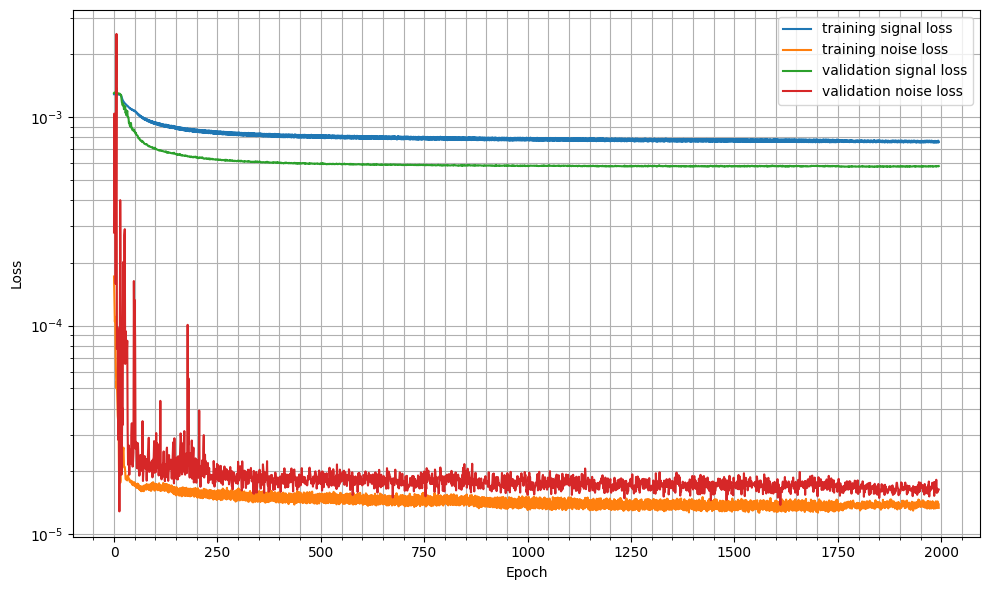

In [4]:
a = data.item()['train_mse_signal']
b = data.item()['train_mse_noise']

plt.figure(figsize=(10, 6))
plt.plot(a[5:], label='training signal loss')
plt.plot(b[5:], label='training noise loss')

# plt.yscale('log')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()
# plt.minorticks_on()
# plt.grid(which='both')
# plt.tight_layout()
# plt.show()

a = data.item()['val_mse_signal']
b = data.item()['val_mse_noise']

#plt.figure(figsize=(10, 6))
plt.plot(a[5:], label='validation signal loss')
plt.plot(b[5:], label='validation noise loss')

plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
#plt.title('Loss Curve')
#plt.ylim(0, 0.55)
plt.minorticks_on()
plt.grid(which='both')
plt.tight_layout()
#plt.savefig('./plots/loss_{}.pdf'.format(version))
#plt.savefig('./plots/loss_{}.png'.format(version))

plt.show()